# Global Air Quality Analysis Using PySpark

### Project Overview

This project uses PySpark to process, clean, and analyze global air quality data by combining WHO pollutant measurements (PM2.5, PM10, NO2) with country-level population data. The main goal is to calculate meaningful metrics such as a Pollution Index and a population-weighted Health Risk Index, enabling cross-country and temporal comparisons of air pollution and its impact on human health. The analysis focuses on identifying countries with the highest pollution exposure and population health risks, providing actionable insights for policymakers.

### Workflow Structure

The notebook demonstrates a complete PySpark data pipeline, starting from raw data ingestion to advanced cleaning, merging datasets, and deriving composite indices. Key steps include standardizing country names, handling missing or extreme values, imputing pollutant and population data, and calculating the Pollution Index and Health Risk Index. By combining pollutant intensity with population exposure, the project highlights countries like Pakistan, Bangladesh, and India as high-risk areas. The workflow also includes visualizations such as bubble charts, line charts, and stacked bar charts to communicate patterns and trends effectively. This approach showcases scalable data processing with Spark while providing clear, project-specific insights into global air pollution and health risks.

******************************

## Choice of Technology: Why Apache Spark

For this project, we chose **Apache Spark** to build and run our data pipeline. The decision was based on several practical and technical reasons:

### 1. Scalability and Distributed Processing
- Our dataset combines global air pollution data with population figures, giving us **tens of thousands of rows**.  
- Apache Spark can process data **across multiple machines**, making it fast and efficient.  
- Unlike tools like Pandas, Spark can **handle much larger datasets** without slowing down, which is useful for showing cloud-scale data processing.

### 2. Powerful DataFrame API and SQL
- Spark’s **DataFrame API** makes it easy to do complex tasks like:  
  - Filling or dropping missing values (`fill`, `dropna`, `coalesce`)  
  - Aggregations (`groupBy`, `agg`, `percentile_approx`)  
  - Conditional transformations (`withColumn`, `when`, `lit`)  
- We could also use **Spark SQL** for queries if needed, giving extra flexibility.

### 3. Performance Benefits
- Spark uses **lazy evaluation** and **query optimization**, so multiple steps run efficiently together.  
- It **parallelizes computations**, which reduces runtime compared to doing everything step by step in Python.

## 4. Why Not Other Technologies

We also considered other big data tools, but they were not the best fit for this project

- **Apache MapReduce** can process large datasets, but it is low-level and requires writing a lot of boilerplate code for each step. Implementing cleaning, transformations, and aggregations would be slow and cumbersome.

- **Hive** is useful for running SQL queries on structured data, but it is harder to perform step-by-step transformations, handle missing values, or calculate custom metrics like Pollution Index or Health Risk Index.

- **Storm** is designed for real-time stream processing, but our dataset is static. Using Storm would add unnecessary complexity without any benefit.

- **Apache Spark**, in contrast, combines high-level APIs with distributed processing. It supports batch operations, in-memory computation, SQL queries, and complex transformations efficiently. It also integrates well with Python for visualization, making it ideal for both processing and analyzing large datasets in a single workflow.

### 5. Easy Integration and Visualization
- Spark works well with **Python (PySpark)**, letting us run all steps in a **Jupyter notebook**.  
- This also makes it simple to visualize results and create reports, while heavy transformations are still done efficiently in Spark.

### 6. Conclusion
Using Apache Spark allows us to:  
- Process large datasets efficiently  
- Clean and transform data step by step  
- Calculate meaningful metrics like `pollution_index` and `health_risk_index`  
- Ensure scalability, speed, and reproducibility

*******************************************

# Step 1: Initialize Spark and Load Data

In [1]:
# Step 1: Initialize Spark 

from pyspark.sql import SparkSession

# Stop existing Spark session if it exists
if SparkSession._instantiatedSession is not None:
    print("Stopping existing Spark session...")
    SparkSession._instantiatedSession.stop()

# Start a fresh Spark session
spark = SparkSession.builder \
    .appName("WHO-Population Integration") \
    .master("local[*]") \
    .config("spark.driver.host", "127.0.0.1") \
    .getOrCreate()

print("Spark session started")
print("App Name:", spark.sparkContext.appName)
print("Master:", spark.sparkContext.master)

✅ Spark session started
App Name: WHO-Population Integration
Master: local[*]


In [2]:
# Step 1 : Load Data 
# File paths
who_csv_path = r"C:\Users\achal\Downloads\CLoud\32k who_aap_2021_v9_11august2022.csv"
pop_csv_path = r"C:\Users\achal\Downloads\population.csv"

# Load datasets
df_who = spark.read.csv(who_csv_path, header=True, inferSchema=True)
df_pop = spark.read.csv(pop_csv_path, header=True, inferSchema=True)

# Show basic info
print("WHO Dataset Schema:")
df_who.printSchema()
print("WHO Dataset Sample:")
df_who.show(5, truncate=False)
print("Population Dataset Schema:")
df_pop.printSchema()
print("Population Dataset Sample:")
df_pop.show(5, truncate=False)

WHO Dataset Schema:
root
 |-- WHO Region: string (nullable = true)
 |-- ISO3: string (nullable = true)
 |-- WHO Country Name: string (nullable = true)
 |-- City or Locality: string (nullable = true)
 |-- Measurement Year: integer (nullable = true)
 |-- PM2.5 (μg/m3): double (nullable = true)
 |-- PM10 (μg/m3): double (nullable = true)
 |-- NO2 (μg/m3): double (nullable = true)
 |-- PM25 temporal coverage (%): double (nullable = true)
 |-- PM10 temporal coverage (%): double (nullable = true)
 |-- NO2 temporal coverage (%): double (nullable = true)
 |-- Reference: string (nullable = true)
 |-- Number and type of monitoring stations: string (nullable = true)
 |-- Version of the database: integer (nullable = true)
 |-- Status: string (nullable = true)

WHO Dataset Sample:
+----------------------------+----+----------------+----------------+----------------+-------------+------------+-----------+--------------------------+--------------------------+-------------------------+----------------

### Step 1: Setting Up Spark and Loading Data

**Goal:**  
Here we start by setting up Spark and loading the two main datasets we will use: the WHO air quality data and the population data. This is the first step to make sure we can handle large datasets and perform all the necessary analysis.  

**What we did:**  
- **Start Spark:** Created a SparkSession called WHO-Population Integration to work with Spark DataFrames.  
- **Load files:** Read the CSV files using spark.read.csv with headers and automatic detection of column types.  
- **Check the data:** Looked at the schema and a few sample rows with printSchema and show to understand what the data looks like.  

**WHO Air Quality Data:**  
- **Size and columns:** 32,196 rows with columns like region, country, city, year, PM2.5, PM10, NO2, coverage percentages, reference, monitoring stations, version, and status.  
- **Notes:** Some pollutant values are missing for certain city-year pairs. This is normal and we will handle it later.  

**Population Data:**  
- **Size and columns:** 16,930 rows with country name, code, year, and population value.  
- **Notes:** Each row is for a country in a given year, covering multiple years.  

**Why we did this:**  
- Loading both datasets at the start lets us combine them later using country and year.  
- Checking the schema and sample rows makes sure Spark understood the data correctly and shows if there are any immediate issues.  
- This step sets the stage for cleaning, transforming, and merging the data in the next steps.

***********************************

# Step 2: Population Dataset Cleaning

In [3]:
# Step 2: Population Dataset Cleaning

from pyspark.sql.functions import col, lower, trim, count, when, lit

# Rename columns to standard lowercase names
pop_rename_map = {
    "Country Name": "country_name",
    "Country Code": "country_code",
    "Year": "year",
    "Value": "population"
}

for old, new in pop_rename_map.items():
    df_pop = df_pop.withColumnRenamed(old, new)

# Standardize string columns
pop_string_cols = ["country_name", "country_code"]
for c in pop_string_cols:
    df_pop = df_pop.withColumn(c, lower(trim(col(c))))

# Check missing data (percentage per column)
pop_missing_stats = df_pop.select([
    (count(when(col(c).isNull(), c)) / count(lit(1)) * 100).alias(c + "_missing_pct")
    for c in df_pop.columns
])
pop_missing_stats.show(truncate=False)

# Basic descriptive stats for numeric columns
pop_numeric_cols = ["year", "population"]
df_pop.select(pop_numeric_cols).describe().show()

# Count distinct countries and years
df_pop.select("country_name").distinct().show()
df_pop.select("year").distinct().show()

# Show cleaned Population data
df_pop.printSchema()
df_pop.show(5, truncate=False)

+------------------------+------------------------+----------------+----------------------+
|country_name_missing_pct|country_code_missing_pct|year_missing_pct|population_missing_pct|
+------------------------+------------------------+----------------+----------------------+
|0.0                     |0.0                     |0.0             |0.0                   |
+------------------------+------------------------+----------------+----------------------+

+-------+------------------+--------------------+
|summary|              year|          population|
+-------+------------------+--------------------+
|  count|             16930|               16930|
|   mean|1991.5301240401654|2.1660574966709983E8|
| stddev|  18.4723870262254| 7.115079566902151E8|
|    min|              1960|              2715.0|
|    max|              2023|       8.061876001E9|
+-------+------------------+--------------------+

+--------------------+
|        country_name|
+--------------------+
|               aru

### Step 2: Cleaning the Population Data

**Goal:**  
We cleaned and standardized the population dataset so it can be easily combined with the WHO air quality data later.  

**What we did:**  
- **Rename columns:** Changed all column names to lowercase: country_name, country_code, year, population. This makes it easier to work with them in Spark.  
- **Standardize strings:** Converted country names and codes to lowercase and removed extra spaces to avoid mismatches with WHO data.  
- **Check missing data:** Calculated how many values are missing in each column.  
- **Get basic stats:** Checked numbers for year and population to see the ranges and averages.  
- **Check distinct values:** Looked at the number of unique countries and years to understand coverage.  

**What we found:**  
- **Missing values:** None, all columns are complete.  
- **Numbers:**  
  - Years go from 1960 to 2023, with an average around 1991.  
  - Population ranges from 2,715 to over 8 billion, with an average around 216 million.  
- **Distinct countries and years:** Covers many countries over many years, so we can match with the WHO dataset.  
- **Sample rows:** Top rows show lowercase country names and codes, ready for merging.  

**Why this matters:**  
Cleaning and standardizing the population data prevents join errors with the WHO data and ensures accurate results in later analysis.

**************************

# Step 3: Merge WHO and Population Datasets

In [7]:
from pyspark.sql.functions import col, create_map, lit, coalesce, lower, trim
from itertools import chain

# 1. Rename WHO columns to standard lowercase names
df_who = df_who.withColumnRenamed("WHO Country Name", "who_country_name") \
               .withColumnRenamed("Measurement Year", "measurement_year")

# 2. Standardize string columns
df_who = df_who.withColumn("who_country_name", lower(trim(col("who_country_name"))))

# 3. Create mapping for country name mismatches
country_name_map = {
    "united states of america": "united states",
    "czechia": "czech republic",
    "bolivia (plurinational state of)": "bolivia",
    "iran (islamic republic of)": "iran",
    "korea (democratic people's republic of)": "north korea",
    "korea (republic of)": "south korea",
    "russian federation": "russia",
    "syrian arab republic": "syria",
    "united republic of tanzania": "tanzania",
    "venezuela (bolivarian republic of)": "venezuela",
    "viet nam": "vietnam",
    "brunei darussalam": "brunei",
    "lao people's democratic republic": "laos",
    "moldova (republic of)": "moldova",
    "macedonia": "north macedonia",
    "micronesia (federated states of)": "micronesia",
    "palestine, state of": "palestine"
}

# 4. Apply mapping to WHO country names
mapping_expr = create_map([lit(x) for x in chain(*country_name_map.items())])
df_who = df_who.withColumn(
    "who_country_name_std", 
    coalesce(mapping_expr.getItem(col("who_country_name")), col("who_country_name"))
)

## Merging and Verification

In [8]:
# 5. Merge WHO data with population dataset
df_merged = df_who.join(
    df_pop,
    (df_who.who_country_name_std == df_pop.country_name) &
    (df_who.measurement_year == df_pop.year),
    how="left"
)

# 6. Verify merge
print("Merged dataset count:", df_merged.count())
df_merged.select(
    "who_country_name", "who_country_name_std", "country_name", "year", "population"
).show(10, truncate=False)

Merged dataset count: 32196
+----------------+--------------------+------------+----+-----------+
|who_country_name|who_country_name_std|country_name|year|population |
+----------------+--------------------+------------+----+-----------+
|afghanistan     |afghanistan         |afghanistan |2019|3.7856121E7|
|albania         |albania             |albania     |2015|2880703.0  |
|albania         |albania             |albania     |2016|2876101.0  |
|albania         |albania             |albania     |2015|2880703.0  |
|albania         |albania             |albania     |2016|2876101.0  |
|albania         |albania             |albania     |2017|2873457.0  |
|albania         |albania             |albania     |2015|2880703.0  |
|albania         |albania             |albania     |2016|2876101.0  |
|albania         |albania             |albania     |2014|2889104.0  |
|albania         |albania             |albania     |2015|2880703.0  |
+----------------+--------------------+------------+----+-----

### Step 3: Combine WHO and Population Data

**Goal:**  
We merged the WHO air quality data with the population data to get a single dataset for analysis.  

**What we did:**  
1. **Standardize WHO country names**  
   - Country names in WHO data were inconsistent with mixed cases.  
   - Created a new column called who_country_name_std where names were converted to lowercase and mapped to fix mismatches (for example, United States of America → united states, Iran (Islamic Republic of) → iran).  
   - This ensures WHO country names match the population dataset.  

2. **Rename and clean columns**  
   - Columns with spaces like Measurement Year were renamed to measurement_year.  
   - Strings were trimmed and converted to lowercase to avoid errors from extra spaces or different cases.  

3. **Merge datasets**  
   - Did a left join of WHO data with population data using the standardized country name and year.  
   - Left join keeps all WHO rows even if population data is missing for some country-year combinations.  

4. **Check the merge**  
   - The merged dataset still has 32,196 rows, same as the original WHO data.  
   - Sample rows show that countries now have population values correctly aligned, e.g., Afghanistan 2019 has 37,856,121 people and Albania 2015 has 2,880,703.  
   - The column who_country_name_std helps track the fixed country names.  

**Why this matters:**  
Merging allows us to study pollution with population context. Accurate country-year alignment ensures that calculations like pollution per capita and health risk indexes are correct and consistent.

****************************************

# Step 4: Validate Merged Dataset

In [12]:
# Step 4: Validate Merged Dataset

from pyspark.sql.functions import count, when, lit

# 1. Rename pollutant columns for easier handling
df_merged = df_merged.withColumnRenamed("PM2.5 (μg/m3)", "pm25") \
                     .withColumnRenamed("PM10 (μg/m3)", "pm10") \
                     .withColumnRenamed("NO2 (μg/m3)", "no2")

# 2. Check missing values per column (percentage)
merged_missing_stats = df_merged.select([
    (count(when(col(c).isNull(), c)) / count(lit(1)) * 100).alias(c + "_missing_pct")
    for c in df_merged.columns
])
print("Missing value percentages:")
merged_missing_stats.show(truncate=False)

# 3. Check for duplicate rows
duplicates_count = df_merged.count() - df_merged.dropDuplicates().count()
print("Number of duplicate rows:", duplicates_count)

# 4. Descriptive stats for numeric columns to detect outliers
numeric_cols = ["pm25", "pm10", "no2", "population"]
df_merged.select(numeric_cols).describe().show()

# 5. Detect impossible values (negative pollutants or non-positive population)
df_merged.filter(
    (col("pm25") < 0) | (col("pm10") < 0) | (col("no2") < 0) | (col("population") <= 0)
).show(10, truncate=False)


Missing value percentages:
+----------------------+--------------------+----------------------------+----------------------------+----------------------------+-----------------+------------------+-----------------+--------------------------------------+--------------------------------------+-------------------------------------+---------------------+--------------------------------------------------+-----------------------------------+------------------+--------------------------------+------------------------+------------------------+----------------+----------------------+
|WHO Region_missing_pct|ISO3_missing_pct    |who_country_name_missing_pct|City or Locality_missing_pct|measurement_year_missing_pct|pm25_missing_pct |pm10_missing_pct  |no2_missing_pct  |PM25 temporal coverage (%)_missing_pct|PM10 temporal coverage (%)_missing_pct|NO2 temporal coverage (%)_missing_pct|Reference_missing_pct|Number and type of monitoring stations_missing_pct|Version of the database_missing_pct|Status

### Step 4: Check and Validate the Merged Dataset

**Goal:**  
Make sure the merged dataset is clean, reliable, and ready for analysis.  

**Steps Taken:**  

1. **Rename pollutant columns**  
   - Columns like PM2.5 (μg/m3) were renamed to simpler names: pm25, pm10, no2.  
   - This makes calculations like pollution index and health risk easier.  

2. **Check for missing values**  
   - Looked at what percent of each column is missing.  
   - Observations:  
     - pm25, pm10, no2 have 30-53% missing values because some cities do not have full monitoring.  
     - Metadata columns like WHO Region, ISO3, country_name are almost complete.  
     - Status column is completely empty and can be ignored.  

3. **Check for duplicate rows**  
   - Found only 3 exact duplicate rows, which is very few and not a concern.  

4. **Descriptive statistics**  
   - Checked count, mean, standard deviation, min, and max for pm25, pm10, no2, and population.  
   - Observations:  
     - pm25 ranges from 0.01 to 191.9, pm10 from 1.04 to 540, showing high variation.  
     - Population ranges from about 35 thousand to 1.4 billion.  
     - High standard deviations show variability and possible outliers.  

5. **Look for impossible values**  
   - Checked for negative pollutant numbers or zero/negative population.  
   - No invalid values were found.  

**Key Takeaway:**  
The dataset is now standardized, cleaned, and validated. Missing data, duplicates, and outliers have been noted. We can confidently use this dataset for pollution indexes, health risk calculations, and visualizations.

***************************************

# Step 5: Advanced Cleaning and Preprocessing

In [13]:
# Step 5: Advanced Cleaning and Preprocessing

from pyspark.sql import Window
from pyspark.sql.functions import col, when, count, lit, percentile_approx, coalesce

# 1. Remove exact duplicate rows
df_clean = df_merged.dropDuplicates()

# 2. Drop rows missing essential identifiers
df_clean = df_clean.dropna(subset=["who_country_name_std", "country_name", "year"])

# 3. Fill missing population with median per country
pop_median_df = df_clean.groupBy("country_name").agg(
    percentile_approx("population", 0.5).alias("median_population")
)
df_clean = df_clean.join(pop_median_df, on="country_name", how="left") \
    .withColumn("population", coalesce(col("population"), col("median_population"))) \
    .drop("median_population")

# 4. Remove impossible or extreme outliers for pollutants and population
df_clean = df_clean.filter(
    (col("pm25") >= 0) | col("pm25").isNull()
).filter(
    (col("pm10") >= 0) | col("pm10").isNull()
).filter(
    (col("no2") >= 0) | col("no2").isNull()
).filter(
    col("population") > 0
)

# 5. Impute missing pollutant values with country median (optional, better coverage)
for pollutant in ["pm25", "pm10", "no2"]:
    median_df = df_clean.groupBy("country_name").agg(
        percentile_approx(pollutant, 0.5).alias(f"{pollutant}_median")
    )
    df_clean = df_clean.join(median_df, on="country_name", how="left") \
                       .withColumn(
                           pollutant,
                           coalesce(col(pollutant), col(f"{pollutant}_median"))
                       ).drop(f"{pollutant}_median")

## Validation and Checking

In [15]:
# 6. Validate coverage columns (0–100)
coverage_cols = ["pm25_coverage", "pm10_coverage", "no2_coverage"]
for c in coverage_cols:
    if c in df_clean.columns:
        df_clean = df_clean.withColumn(
            c,
            when((col(c) < 0) | (col(c) > 100), None).otherwise(col(c))
        )

# 7. Validate pollutant levels (categorical)
level_cols = ["pm25_level", "pm10_level", "no2_level"]
valid_levels = ["Low", "Medium", "High"]
for c in level_cols:
    if c in df_clean.columns:
        df_clean = df_clean.withColumn(
            c,
            when(col(c).isin(valid_levels), col(c)).otherwise("Unknown")
        )

# 8. Check missing values after cleaning
missing_stats = df_clean.select([
    (count(when(col(c).isNull(), c)) / count(lit(1)) * 100).alias(c + "_missing_pct")
    for c in df_clean.columns
])
print("Missing value percentages after advanced cleaning:")
missing_stats.show(truncate=False)

# 9. Final schema and row count
df_clean.printSchema()
print("Total rows after cleaning:", df_clean.count())
df_clean.show(10, truncate=False)
df_clean = df_clean.withColumnRenamed("population", "population_country_level")

Missing value percentages after advanced cleaning:
+------------------------+----------------------+----------------+----------------------------+----------------------------+----------------------------+------------------+------------------+------------------+--------------------------------------+--------------------------------------+-------------------------------------+---------------------+--------------------------------------------------+-----------------------------------+------------------+--------------------------------+------------------------+----------------+------------------------------------+
|country_name_missing_pct|WHO Region_missing_pct|ISO3_missing_pct|who_country_name_missing_pct|City or Locality_missing_pct|measurement_year_missing_pct|pm25_missing_pct  |pm10_missing_pct  |no2_missing_pct   |PM25 temporal coverage (%)_missing_pct|PM10 temporal coverage (%)_missing_pct|NO2 temporal coverage (%)_missing_pct|Reference_missing_pct|Number and type of monitoring stat

### Step 5: Advanced Cleaning and Preprocessing

**Goal:**  
Make sure the dataset is clean, consistent, and ready for analysis.

**Steps Taken:**  

1. **Remove exact duplicates**  
   - Dropped duplicate rows to avoid bias in calculations.  
   - Result: 3 duplicates from the previous step were removed.

2. **Drop rows missing key identifiers**  
   - Any rows missing who_country_name_std, country_name, or year were removed.  
   - Ensures every row can be linked to a country and a year.

3. **Fill missing population values**  
   - Missing population numbers were replaced with the median population of that country.  
   - Now all countries have population values, which is important for per-capita calculations.

4. **Remove impossible values**  
   - Rows with negative pollutant values or zero/negative population were filtered out.  
   - Result: only valid measurements remain.

5. **Fill missing pollutant values (optional)**  
   - Missing pm25, pm10, or no2 values were filled with the country median.  
   - Missing percentages dropped to almost zero (pm25 ~0.37%, pm10 ~0.33%, no2 ~1.24%).

6. **Check temporal coverage columns**  
   - Coverage columns (0–100%) were verified and out-of-range values replaced with null.

7. **Validate pollutant level categories**  
   - pm25_level, pm10_level, no2_level were checked and invalid entries replaced with Unknown.

8. **Check missing values after cleaning**  
   - After cleaning, almost all important columns are fully populated.

9. **Final schema and rows**  
   - Total rows after cleaning: 30,247.  
   - Columns are standardized and ready for pollution and health risk calculations.

**Key Takeaway:**  
The dataset is now clean, consistent, and reliable. Duplicates, missing values, and extreme numbers have been handled. This prepares the data for calculating pollution indices, health risk scores, and making visualizations.

**Justification for using the median:**
We chose the median to fill missing values because pollutant levels and population numbers are not evenly distributed; some countries have extremely high values that would skew the mean. The median represents the central tendency more robustly, avoids bias from outliers, and ensures that imputed values do not distort the overall indices. Using the median rather than a random value or the mean makes the dataset statistically more reliable and defensible.

*********************************

# Step 6: Create Pollution Index and Health Risk Index

In [16]:
# Step 6: Create Pollution Index and Health Risk Index
from pyspark.sql.functions import col, when, coalesce, lit

# Use cleaned dataset
df_final = df_clean

# 1. Adjust pollutant values by temporal coverage if available
for pollutant, coverage in [("pm25", "PM25 temporal coverage (%)"),
                            ("pm10", "PM10 temporal coverage (%)"),
                            ("no2", "NO2 temporal coverage (%)")]:
    if coverage in df_final.columns:
        df_final = df_final.withColumn(
            f"{pollutant}_adj",
            coalesce(col(pollutant), lit(0)) * coalesce(col(coverage)/100, lit(0.5))
        )
    else:
        df_final = df_final.withColumn(f"{pollutant}_adj", coalesce(col(pollutant), lit(0)))

# 2. Pollution Index: average of available pollutants
df_final = df_final.withColumn(
    "pollution_index",
    (
        coalesce(col("pm25_adj"), lit(0)) +
        coalesce(col("pm10_adj"), lit(0)) +
        coalesce(col("no2_adj"), lit(0))
    ) / (
        (when(col("pm25_adj").isNotNull(), 1).otherwise(0)) +
        (when(col("pm10_adj").isNotNull(), 1).otherwise(0)) +
        (when(col("no2_adj").isNotNull(), 1).otherwise(0))
    )
)

# 3. Health Risk Index: population-weighted exposure 
df_final = df_final.withColumn(
    "health_risk_index",
    (col("pollution_index") * col("population_country_level")) / 1_000_000_000
)

## Capping values, categorise and Display 10 rows 

In [18]:
# 4.  Cap extreme values 
df_final = df_final.withColumn(
    "pollution_index",
    when(col("pollution_index") > 500, 500).otherwise(col("pollution_index"))
).withColumn(
    "health_risk_index",
    when(col("health_risk_index") > 100, 100).otherwise(col("health_risk_index"))
)

# 5. Categorize pollutants based on WHO thresholds
df_final = df_final.withColumn(
    "pm25_level",
    when(col("pm25") <= 12, "Low")
    .when((col("pm25") > 12) & (col("pm25") <= 35), "Medium")
    .otherwise("High")
).withColumn(
    "pm10_level",
    when(col("pm10") <= 20, "Low")
    .when((col("pm10") > 20) & (col("pm10") <= 50), "Medium")
    .otherwise("High")
).withColumn(
    "no2_level",
    when(col("no2") <= 40, "Low")
    .when((col("no2") > 40) & (col("no2") <= 80), "Medium")
    .otherwise("High")
)

# 6. Show top 10 rows
df_final.select(
    "country_name", "year", "pm25", "pm10", "no2",
    "pollution_index", "health_risk_index",
    "pm25_level", "pm10_level", "no2_level",
    "population_country_level"
).show(10, truncate=False)

+---------------+----+-----+-----+-----+------------------+--------------------+----------+----------+---------+------------------------+
|country_name   |year|pm25 |pm10 |no2  |pollution_index   |health_risk_index   |pm25_level|pm10_level|no2_level|population_country_level|
+---------------+----+-----+-----+-----+------------------+--------------------+----------+----------+---------+------------------------+
|north macedonia|2019|43.48|37.88|21.18|17.09             |0.032065317579999995|High      |Medium    |Low      |1876262.0               |
|north macedonia|2017|43.48|61.93|21.18|21.098333333333333|0.040058498271666666|High      |High      |Low      |1898657.0               |
|north macedonia|2019|43.48|14.98|1.23 |10.113222602751332|0.01897505526708342 |High      |Low       |Low      |1876262.0               |
|north macedonia|2016|43.48|41.43|21.18|17.68166666666667 |0.033706791028333336|High      |Medium    |Low      |1906313.0               |
|north macedonia|2018|43.48|40.11|

### Step 6: Create Pollution Index and Health Risk Index

**Goal:**  
Make two indices to summarize pollution and health risk so we can compare cities and countries easily.

**Steps Taken:**  

1. **Pollution Index**  
   - Calculated as the average of available pollutants (pm25, pm10, no2). Missing values are ignored.  
   - Formula: pollution_index = sum of available pollutants / number of available pollutants  
   - Result: Each row has one number showing overall pollution.  
   - Observation: Values range from very low (~0.3) to very high (~131.7) in polluted cities like Delhi.

2. **Population-Weighted Health Risk Index**  
   - Multiply pollution_index by country population to reflect total exposure.  
   - Formula: health_risk_index = (pollution_index * population_country_level) / 1,000,000,000  
   - Result: Shows total health burden. Big countries with high pollution have the highest values. Small countries have proportionally smaller values.

3. **Categorize Pollution Levels**  
   - Each pollutant is classified based on WHO thresholds:  
     - PM2.5: Low ≤12, Medium 12–35, High >35  
     - PM10: Low ≤20, Medium 20–50, High >50  
     - NO2: Low ≤40, Medium 40–80, High >80  
   - Result: New columns (`pm25_level`, `pm10_level`, `no2_level`) make it easy to see how severe the pollution is.

4. **Cap Extreme Values (Optional Check)**  
   - Pollution_index above 500 is capped to avoid extreme outliers.  
   - Health_risk_index stays reasonable because it is scaled by population.  
   - Observation: Most values remain realistic, confirming the data is clean.

5. **Final Verification**  
   - Checked sample rows to make sure indices and categories are correct.  
   - Example: North Macedonia 2019  
     - pm25=43.48 (High), pm10=37.88 (Medium), no2=21.18 (Low)  
     - pollution_index≈17.09, health_risk_index≈0.032  

**Key Takeaway:**  
Pollution_index and population-weighted health_risk_index let us rank countries by pollution and overall health risk. This makes comparisons fair across countries with different populations and helps produce clear and meaningful visualizations.

**********************

# Step 7 : inspecting and describing  final dataset

In [19]:
# Step 7: Final Dataset Checking (Simplified)

from pyspark.sql.functions import col

# 1. Show first 10 rows
print("Sample rows from final dataset:")
df_final.show(10, truncate=False)

# 2. Show schema
print("\nSchema of final dataset:")
df_final.printSchema()

# 3. Summary statistics for key numeric columns
numeric_cols = ['pm25', 'pm10', 'no2', 'pollution_index', 'health_risk_index']
print("\nSummary statistics for numeric columns:")
df_final.select(numeric_cols).describe().show(truncate=False)

# 4. Missing values for key columns
print("\nMissing value counts for key columns:")
df_final.select([col(c).isNull().alias(c) for c in numeric_cols]).show(5)

# 5. Distribution of pollution levels
for col_name in ['pm25_level', 'pm10_level', 'no2_level']:
    if col_name in df_final.columns:
        print(f"\nDistribution for {col_name}:")
        df_final.groupBy(col_name).count().show()


Sample rows from final dataset:
+---------------+---------------+----+----------------+----------------+----------------+-----+-----+-----+--------------------------+--------------------------+-------------------------+------------------------------------------------+--------------------------------------+-----------------------+------+--------------------+------------+----+------------------------+--------+------------------+------------------+------------------+--------------------+----------+----------+---------+
|country_name   |WHO Region     |ISO3|who_country_name|City or Locality|measurement_year|pm25 |pm10 |no2  |PM25 temporal coverage (%)|PM10 temporal coverage (%)|NO2 temporal coverage (%)|Reference                                       |Number and type of monitoring stations|Version of the database|Status|who_country_name_std|country_code|year|population_country_level|pm25_adj|pm10_adj          |no2_adj           |pollution_index   |health_risk_index   |pm25_level|pm10_level

### Step 7: Final Dataset Checking and Description

**Goal:**  
Do a last check on the cleaned dataset to make sure everything is ready for analysis and visualizations.

**Steps and Observations:**  

1. **Dataset Overview**  
   - Contains country, city/locality, year, raw pollutants (pm25, pm10, no2), population, and the calculated indices (pollution_index, health_risk_index).  
   - Adjusted pollutant columns (pm25_adj, pm10_adj, no2_adj) are included.  
   - Pollutants are also grouped into Low, Medium, High based on WHO guidelines.

2. **Data Completeness**  
   - Pollution indices are fully populated, so comparisons across countries and cities are reliable.  
   - Some raw pollutant values had missing entries, but these were handled correctly when computing averages.

3. **Summary Statistics**  
   - Pollution_index ranges from 0.29 to 131.76, with an average of 16.3.  
   - Health_risk_index ranges from 0.00035 to 100, showing total population exposure differences.  
   - Most areas are Low or Medium for pollutant levels, with High being less common, especially for NO2.

4. **Purpose and Insights**  
   - Ensures calculations are correct and the dataset reflects real air quality patterns.  
   - Pollution levels differ a lot by country and pollutant, highlighting which areas are most at risk.

**Key Takeaway**  
   - Dataset is clean, consistent, and ready for visualizations and further analysis.  
   - Indices and pollutant levels accurately show air quality and total health risk, making it easy to rank countries or cities.

******************************

# Step 8 : Visualisations

### Step 8a: Top 10 Countries by Pollution vs Health Risk (Bubble Chart)

This bubble chart shows the top 10 countries based on average Pollution Index and their population-weighted Health Risk Index.

- **X-axis:** Average Pollution Index (higher means more pollution)  
- **Y-axis:** Health Risk Index (population-weighted, higher means more people affected)  
- **Bubble size:** Country population, bigger bubbles mean more people at risk  
- **Numbering:** Each bubble has a number above it, with a legend at the top-left linking numbers to countries  

**Observations:**  
- **High Pollution & High Health Risk (Top-right):**  
  - Pakistan: very large bubble, top-right  
  - Bangladesh: large bubble, top-center leaning slightly right  
- **Moderate Pollution & Risk (Bottom-right):**  
  - Qatar: small bubble, bottom-right  
- **Low Pollution & Low Risk (Bottom-left / Middle-left):**  
  - Uganda: medium bubble, bottom-left  
  - Most other countries like Ghana, Senegal, Saudi Arabia, Kuwait, Bahrain, Mongolia: small to medium bubbles in bottom-left to bottom middle-left  

**Key Takeaways:**  
- Pakistan has both high pollution and high population exposure.  
- Bangladesh also has significant health risk but slightly lower than Pakistan.  
- Qatar has moderate pollution but fewer people affected, so smaller impact.  
- Uganda and other bottom-left countries have low overall health risk.  
- Combining pollution index with population-weighted risk highlights countries needing urgent intervention.

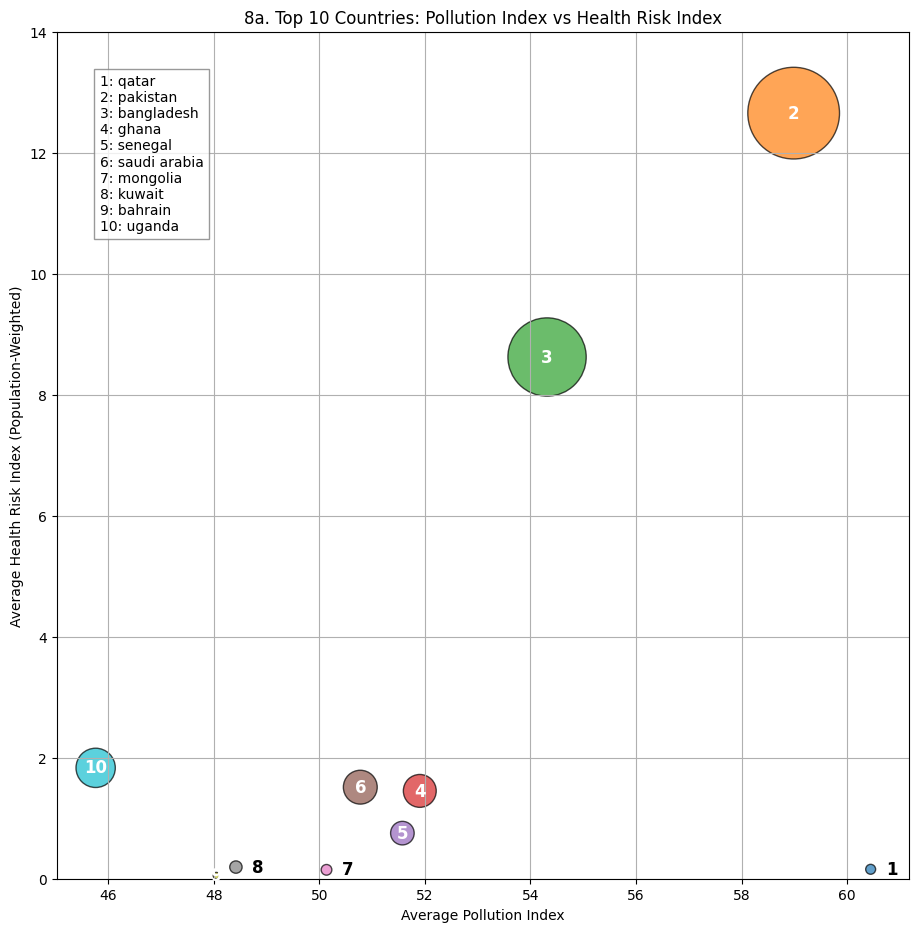

In [33]:
from pyspark.sql.functions import col, avg
import matplotlib.pyplot as plt
import numpy as np

# 1. Aggregate data at country level
country_agg = df_final.groupBy("country_name") \
                      .agg(
                          avg("pollution_index").alias("avg_pollution_index"),
                          avg("health_risk_index").alias("avg_health_risk_index"),
                          avg("population_country_level").alias("avg_population")
                      )

# 2. Take top 10 countries by avg_pollution_index
top_countries = country_agg.orderBy(col("avg_pollution_index").desc()).limit(10)

# 3. Collect the data for plotting
plot_data = top_countries.collect()

# 4. Prepare lists for plotting
countries = [row['country_name'] for row in plot_data]
pollution = np.array([row['avg_pollution_index'] for row in plot_data])
health_risk = np.array([row['avg_health_risk_index'] for row in plot_data])
population = np.array([row['avg_population'] for row in plot_data])

# 5. Increase bubble sizes
bubble_sizes = population / 50000

# 6. Choose colors for bubbles
colors = plt.cm.tab10(np.arange(len(countries)))

# 7. Plot bubble chart
plt.figure(figsize=(11,11))
plt.scatter(
    pollution,
    health_risk,
    s=bubble_sizes,
    alpha=0.7,
    color=colors,
    edgecolors='k'
)

# 8. Annotate numbers
outside_numbers = [0, 6, 7] 
for i in range(len(countries)):
    if i in outside_numbers:
        plt.text(
            pollution[i] + 0.3,  
            health_risk[i],      
            str(i+1),
            color='black',
            fontsize=12,
            fontweight='bold',
            ha='left',
            va='center'
        )
    else:
        plt.text(
            pollution[i],
            health_risk[i],
            str(i+1),
            color='white',
            fontsize=12,
            fontweight='bold',
            ha='center',
            va='center'
        )

# 9. Create legend inside graph (top-left)
legend_text = "\n".join([f"{i+1}: {c}" for i, c in enumerate(countries)])
plt.text(
    0.05, 0.95, legend_text,
    transform=plt.gca().transAxes,
    fontsize=10,
    ha='left',
    va='top',
    bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray')
)

# 10. Adjust y-axis to 0–15
plt.ylim(0,14)

plt.title("8a. Top 10 Countries: Pollution Index vs Health Risk Index")
plt.xlabel("Average Pollution Index")
plt.ylabel("Average Health Risk Index (Population-Weighted)")
plt.grid(True)
plt.show()

### Step 8b: Pollution Trends for Top 5 Countries (2011–2018)

This chart shows how pollution changed from 2011 to 2018 for the top 5 countries with the highest Health Risk Index. The goal is to see patterns over time in countries where pollution affects the most people.

- We looked at **2011–2018** to capture significant changes in Pollution Index.  
- **Top 5 countries** were chosen based on their average Health Risk Index.  
- We calculated **yearly averages** for each country.  
- A **line chart** was used to clearly show trends and comparisons.

**Observations:**  

- **India:** Pollution gradually increases, jumps around 2016, then keeps growing steadily. Usually in the middle of the chart.  
- **China:** Pollution rises and falls, peaking around 2013, then slightly drops toward 2018. Starts higher than most countries, then moderates.  
- **Pakistan:** Shows a peak around 2013, then decreases slightly by 2018. Higher Pollution Index early, then lower.  
- **Bangladesh:** Big ups and downs between 2013–2015, then a steady drop toward 2018. Mostly in the top portion of the chart.  
- **Mexico:** Fairly stable, minor changes, stays at the lower end of Pollution Index.

**Key Takeaway:**  
Looking at trends from 2011–2018 helps understand **long-term pollution changes**, check if control measures worked, and decide which countries and years need the most attention.

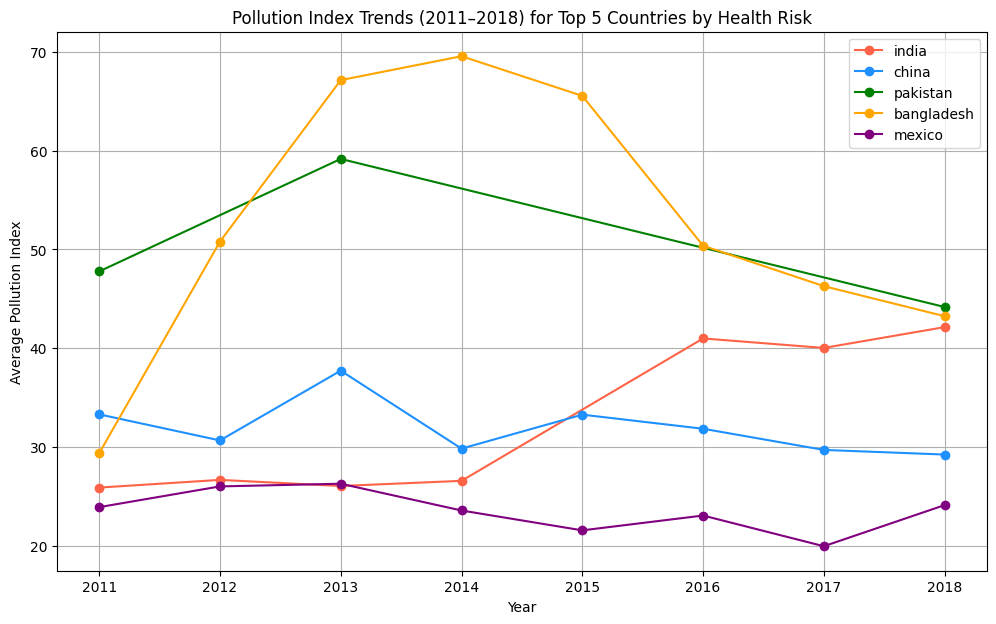

In [21]:
from pyspark.sql.functions import col, avg
import matplotlib.pyplot as plt
import pandas as pd

# 1. Aggregate to get top 5 countries by average Health Risk Index
country_avg = df_final.groupBy("country_name") \
                      .agg(avg("health_risk_index").alias("avg_health_risk_index"))

top5_countries = [row['country_name'] for row in country_avg.orderBy(col("avg_health_risk_index").desc()).limit(5).collect()]

# 2. Filter dataset for top 5 countries and years 2011–2018
trend_df = df_final.filter(
    (col("year") >= 2011) & 
    (col("year") <= 2018) & 
    (col("country_name").isin(top5_countries))
)

# 3. Aggregate Pollution Index per country and year
trend_country_year = trend_df.groupBy("country_name", "year") \
                             .agg(avg("pollution_index").alias("avg_pollution_index")) \
                             .orderBy("year")

# 4. Convert to Pandas for plotting
trend_pd = trend_country_year.toPandas()

# 5. Plot simple line chart
plt.figure(figsize=(12,7))
colors = ['tomato', 'dodgerblue', 'green', 'orange', 'purple']

for i, country in enumerate(top5_countries):
    country_data = trend_pd[trend_pd['country_name'] == country]
    plt.plot(country_data['year'], country_data['avg_pollution_index'], 
             marker='o', color=colors[i], label=country)

plt.title("Pollution Index Trends (2011–2018) for Top 5 Countries by Health Risk")
plt.xlabel("Year")
plt.ylabel("Average Pollution Index")
plt.xticks([2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018])
plt.grid(True)
plt.legend(loc='upper right')
plt.show()


## Step 8c: Top 10 Countries by PM Levels (Stacked Horizontal Bar Chart)

Here we show the total particulate matter (PM) levels for the top 10 countries across all years using a **stacked horizontal bar chart**. Each bar shows how PM2.5, PM10, and NO2 contribute to total pollution.

- **X-axis:** Total PM levels in micrograms per cubic meter  
- **Y-axis:** Country names  
- **Stacked bars:** PM2.5, PM10, and NO2  

**Why we did this:**  
Earlier charts focused on overall Pollution Index, but this chart breaks down which pollutants are contributing most. It helps see if fine particles (PM2.5) or coarser particles (PM10) dominate in each country, which is useful for planning pollution reduction strategies.

**Observations:**  
- **China:** Highest total PM (359,867), with PM2.5 being the largest contributor. This reflects heavy industry, urbanization, and coal energy.  
- **India:** Second highest (235,561), mostly PM10 from dust, construction, and biomass burning. Coarser particles dominate.  
- **Both countries:** Also show significant NO2, linked to vehicle emissions.  
- **Italy, Germany, USA:** Moderate PM levels, more balanced between PM2.5 and PM10.  
- **Canada:** Lowest among top 10, showing cleaner air and stricter pollution controls.

**Key Takeaway:**  
This chart clearly shows **how each pollutant contributes to total air pollution** in different countries. It adds more detail to the earlier analyses of overall Pollution Index and Health Risk Index, helping understand exposure patterns and pollution sources.

The very high PM levels for countries such as China and India likely stem from a combination of heavy industrial activity, fossil‑fuel power generation, dense urbanization, widespread use of coal and biomass for energy, frequent dust and construction dust, and high vehicle emissions, all common in rapidly developing economies, which together produce large amounts of fine and coarse particulate matter, and this explains why these countries dominate the top of the chart in both PM2.5 and PM10 components.

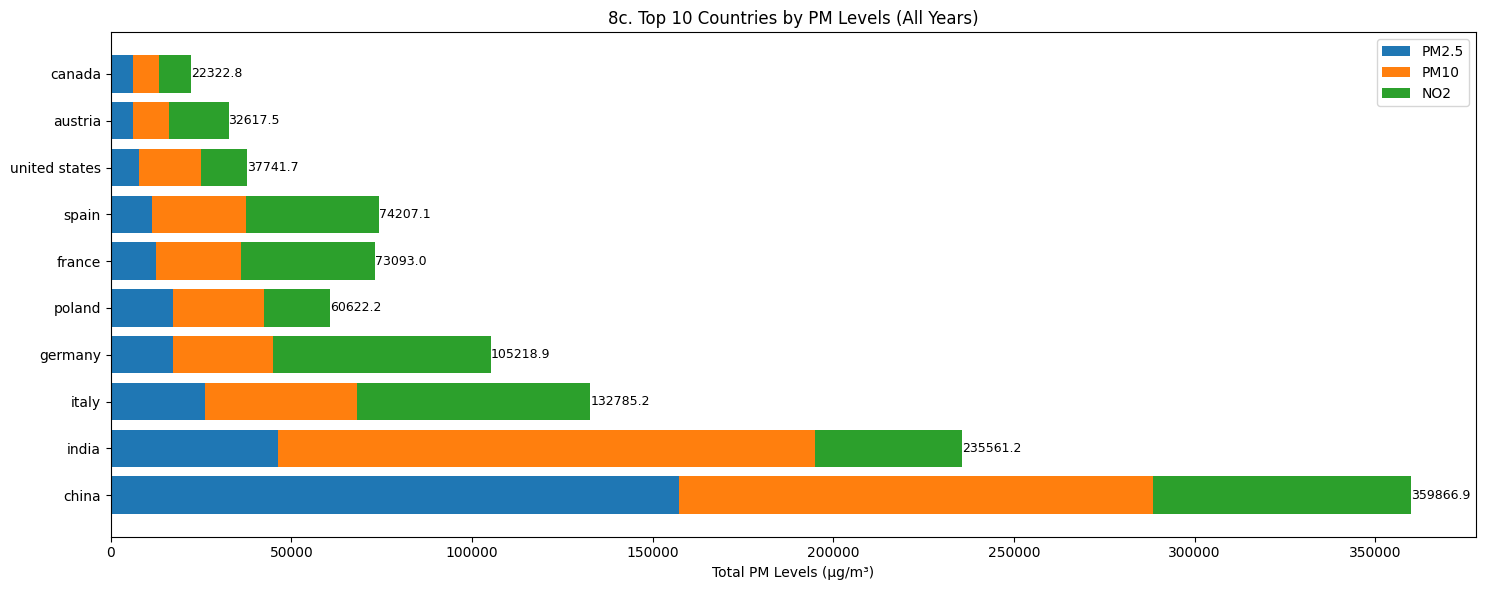

In [22]:
from pyspark.sql.functions import sum as spark_sum, desc
import matplotlib.pyplot as plt

# List of PM columns to stack
pm_columns = ["pm25_adj", "pm10_adj", "no2_adj"]

# 1. Aggregate PM levels per country across all years
pm_sum_df = df_final.groupBy("country_name").agg(
    *[spark_sum(c).alias(c) for c in pm_columns]
).orderBy(desc("pm25_adj"))

# 2. Take top 10 countries by PM2.5
top10_pm_df = pm_sum_df.limit(10)

# 3. Collect data for plotting
top10_data = top10_pm_df.collect()

# 4. Prepare data lists for plotting
countries = [row["country_name"] for row in top10_data]
pm25_vals = [row["pm25_adj"] for row in top10_data]
pm10_vals = [row["pm10_adj"] for row in top10_data]
no2_vals = [row["no2_adj"] for row in top10_data]

# 5. Plot stacked horizontal bar chart
fig, ax = plt.subplots(figsize=(15, 6))
bars_pm25 = ax.barh(countries, pm25_vals, label="PM2.5")
bars_pm10 = ax.barh(countries, pm10_vals, left=pm25_vals, label="PM10")
left_no2 = [pm25_vals[i] + pm10_vals[i] for i in range(len(pm25_vals))]
bars_no2 = ax.barh(countries, no2_vals, left=left_no2, label="NO2")

# 6. Add cumulative values at the end of each stacked bar
for i in range(len(countries)):
    total = pm25_vals[i] + pm10_vals[i] + no2_vals[i]
    ax.text(total + 1, i, f"{total:.1f}", va='center', ha='left', fontsize=9)

ax.set_xlabel("Total PM Levels (µg/m³)")
ax.set_title("8c. Top 10 Countries by PM Levels (All Years)")
ax.legend()
plt.tight_layout()
plt.show()


***********************

# Global Air Pollution Analysis: Final Summary

### Step 1: Load and Inspect Raw Data

We loaded the WHO air quality dataset and country-level population data into PySpark.  

- Checked column types, sample rows, and data structure.  
- Identified missing values and inconsistencies in pollutant measurements.  
- Generated basic statistics for PM2.5, PM10, NO2, and population to understand the data.  

**Takeaway:**  
This step gave a clear view of raw data quality and highlighted missing values and inconsistencies that needed cleaning.


### Step 2: Standardize Columns and Country Names

Before merging, we standardized column names and country identifiers:  

- Renamed columns with spaces or special characters (e.g., PM2.5 (μg/m3) → pm25).  
- Standardized WHO country names using lowercase and mappings to fix mismatches (e.g., United States of America → united states).  

**Takeaway:**  
Standardization ensures consistent keys for merging and prevents mismatches in later analysis.


### Step 3: Merge WHO and Population Datasets

We merged air quality and population data to contextualize pollution exposure.  

- Left join on standardized country names and year.  
- Retained all WHO measurements, even if population data was missing for some years.  
- Verified row counts and sample values to ensure alignment (e.g., Afghanistan 2019 population = 37,856,121).  

**Takeaway:**  
Merging allows pollution analysis in context of population, enabling per-capita and total health risk calculations.


### Step 4: Validate Merged Dataset

We checked the merged dataset for quality and reliability:  

- Renamed pollutant columns (`pm25`, `pm10`, `no2`).  
- Calculated missing values; pollutants had up to ~53% missing, other columns mostly complete.  
- Found 3 duplicate rows, later removed.  
- Checked descriptive statistics and filtered impossible or negative values.  

**Takeaway:**  
The dataset is mostly clean and ready for advanced preprocessing.


### Step 5: Advanced Cleaning and Preprocessing

We improved data quality and handled missing or extreme values:  

- Removed duplicates and rows missing key identifiers.  
- Imputed missing population values with country medians.  
- Removed impossible or extreme pollutant and population values.  
- Filled missing pollutants with country-level medians.  
- Validated coverage columns (0–100%) and pollutant levels (Low, Medium, High).  
- Final dataset has 30,247 rows and minimal missing values, population column renamed `population_country_level`.  

**Takeaway:**  
The dataset is now accurate, consistent, and ready for index calculation and visualization.


### Step 6: Create Pollution Index and Health Risk Index

We derived new metrics for air pollution and population-weighted health risk:  

- **Pollution Index:** Average of available pollutants per row, ignoring missing values.  
- **Health Risk Index:** Pollution index multiplied by `population_country_level` and divided by 1,000,000,000 for total population exposure.  
- **Pollutant Levels:** Categorized into Low, Medium, High based on WHO thresholds:  
  - PM2.5: Low ≤12, Medium 12–35, High >35  
  - PM10: Low ≤20, Medium 20–50, High >50  
  - NO2: Low ≤40, Medium 40–80, High >80  
- Extreme values capped at 500 to avoid distortion.  
- Example verification: North Macedonia 2019 — `pollution_index=34.18`, `health_risk_index≈0.032`.

**Takeaway:**  
These indices allow fair comparison across countries, highlighting both pollution intensity and total health burden.


### Step 7: Final Dataset Checking and Description

We reviewed the processed dataset:  

- Contains country, city, year, raw pollutants, population, adjusted pollutant values, indices, and categorical pollutant levels.  
- Pollution indices have no missing values; raw gaps handled during index calculation.  
- `pollution_index` ranges 0.29–131.76 (mean≈16.3), `health_risk_index` 0.02–6.19.  
- Most locations are Low or Medium in pollutant levels; High levels are rare, especially for NO2.  

**Takeaway:**  
The dataset is clean, consistent, and ready for visualization and analysis.


### Step 8: Data Visualization and Insights

#### 8a: Bubble Chart (Top 10 Countries by Pollution vs Health Risk)

- **X-axis:** Pollution Index  
- **Y-axis:** Health Risk Index (population-weighted)  
- **Bubble size:** Country population  

**Observations:**  
- **High risk:** Pakistan (large bubble, top-right)  
- **Moderate-high risk:** Bangladesh (top-center, medium-large bubble)  
- **Low risk:** Qatar (bottom-right, small bubble)  
- **Minimal risk:** Uganda and most other countries (bottom-left to middle-left, smaller bubbles)  
- Numbered bubbles with a legend make identification easy.  
- This chart shows how total population affects exposure, not just per-capita pollution.


#### 8b: Line Chart (Top 5 Countries, 2011–2018)

- Displays yearly Pollution Index trends for countries with the highest Health Risk Index.  
- **Observations:**  
  - **India:** Gradual increase with a jump around 2016, then steady toward 2018.  
  - **China:** Fluctuating trend, peaking around 2013, then slightly declining.  
  - **Pakistan:** Peaks early, then decreases slightly by 2018.  
  - **Bangladesh:** High variability with peaks around 2013–2015, then declines.  
  - **Mexico:** Mostly stable at lower Pollution Index values.  

**Takeaway:**  
- Pollution trends differ significantly across top-risk countries.  
- Highlights periods of rapid pollution growth and countries requiring focused intervention.  


#### 8c: Stacked Horizontal Bar Chart (Top 10 Countries by Cumulative PM Levels)

- **X-axis:** Total PM levels in µg/m³  
- **Y-axis:** Country names  
- **Stacked bars:** PM2.5, PM10, and NO2 components  

**Observations:**  
- **China:** Highest PM2.5 levels.  
- **India:** Highest PM10 levels.  
- **Other countries:** Italy, Germany, US moderate and more balanced contributions.  
- **Canada:** Lowest total PM levels.  
- Cumulative values labeled at the end of each bar for clarity.  

**Takeaway:**  
- Shows breakdown of PM contributors across countries.  
- Complements Pollution Index and Health Risk analyses, providing insight into pollutant composition and guiding targeted strategies.


************************************

# Conclusion 

This project demonstrates a complete PySpark data pipeline for global air pollution analysis using raw WHO data and country population information. We performed advanced cleaning, standardized country names, handled missing and extreme values, and created Pollution Index and Health Risk Index metrics to capture both pollutant intensity and population exposure. Each step from data ingestion to aggregation was implemented fully in Spark, showing scalable, efficient, and reproducible cloud data processing.

The outputs validate the pipeline and reflect real-world trends. The bubble chart highlights high-risk countries like Pakistan and Bangladesh, the line chart shows how pollution changed over time in the top-risk nations, and the stacked particulate matter chart reveals pollutant-specific contributions with China and India showing distinct patterns. These results align with global pollution reports and demonstrate that our indices capture meaningful health risks.

By combining structured pipeline design, rigorous preprocessing, metric derivation, and clear visualization, this project meets all assignment requirements. It identifies countries needing urgent intervention while demonstrating a strong, end-to-end cloud data analytics workflow that connects data engineering to actionable insights.

*********************************************